In [1]:
# Basic python
import sys, os
import warnings
warnings.filterwarnings('ignore')

# Logging
import logging
logging.getLogger().setLevel(logging.INFO)

# Data analysis
import pandas as pd
import numpy as np

# Statistics for ML
from scipy.stats import chi2

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP + ML
import spacy

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)

# Project modules
sys.path.append(os.path.abspath("src"))
from data_ravers_utils.file_handler import read_df_pickle, save_model_pickle, PROJECT_ROOT
from data_ravers_utils.text_features import TextFeatureExtractor

# SpaCy model
try:
    nlp_es = spacy.load("es_core_news_sm")
except OSError:
    raise OSError("SpaCy model not found. Run: python -m spacy download es_core_news_sm")


# EDA takeovers - modelling notes

- Sentence length alone is not a strong discriminator, but:
  - outlier length (very long sentences) may serve as a weak signal for machine-translated text.
  - variance of sentence length is slightly higher for machine translations and might combine well with other features.
- Based on this, length-related features worth keeping:
  - **word_count**
  - **is_outlier_length** (e.g., >95th percentile)
  - **log_length** (to compress extreme values)

Strong signals

These are good candidates for engineered features:
- comma_count
- period_count
- exclamation_count
- ellipsis_count
- quote_count

These show the largest separation between classes.

Moderate signals
- dash_count
- parenthesis_count

May be useful in combination with other features.

Weak or noisy signals
- semicolons
- colons
These appear too rarely to matter statistically.

- **Stopword distributions** (e.g., relative frequencies or normalized counts) can serve as useful discriminative features.
- **Contraction frequency** (e.g., *del*, *al*) may help separate human from machine outputs.
- **Presence of numeric artifacts** (tokens like “1”) is a strong indicator of machine translation.
- N-gram–based models (TF-IDF + Logistic Regression/SVM) will naturally capture these frequency-based differences.

Linguistic features analysis confirms that machine translations:
- produce slightly **longer sentences**,  
- use **more adjectives** and slightly **fewer verbs**,  
- create **inflated entity counts**,  
- and exhibit **more structural/spacing/encoding artifacts**.

Human translations:
- show more **balanced sentence structure**,  
- use **verbs and pronouns more naturally**,  
- contain **more fluent contractions and fewer errors**,  
- and avoid noisy patterns like stray hyphens or encoding failures.

These findings support the idea that both **surface-level features** (punctuation, stopwords) and **linguistic features** (POS ratios, entity behavior) can help distinguish between machine and human translations.


# Feature Candidates from EDA

| Column name            | Signal strength | Rationale | Extraction notes |
|------------------------|-----------------|-----------|------------------|
| **word_count**         | Moderate        | Captures sentence length differences; machines tend to produce slightly longer sentences. | |
| **log_length**         | Moderate        | Compresses extreme sentence outliers; helps stabilize models when MT outputs unusually long sentences. | Apply log(1 + word_count). |
| **is_outlier_length**  | Weak–Moderate   | Extremely long sentences are more common in machine translations. | Use >95th percentile or similar threshold. |
|------------------------|-----------------|-----------|------------------|
| **comma_count**        | Strong          | Machines overuse commas due to rigid clause segmentation. | |
| **period_count**       | Strong          | MT outputs rely heavily on periods, producing flat, segmented text. | |
| **exclamation_count**  | Strong          | Humans use expressive punctuation more often (¡ !). | |
| **ellipsis_count**     | Strong          | Humans use ellipses to convey narrative pacing; machines rarely do. | |
| **quote_count**        | Strong          | Humans introduce quoted speech more naturally. | |
|------------------------|-----------------|-----------|------------------|
| **dash_count**         | Moderate        | Machines sometimes use more hyphens/dashes due to formatting artifacts. | |
| **parenthesis_count**  | Moderate        | Structural punctuation shows small differences and can support other features. | |
|------------------------|-----------------|-----------|------------------|
| **semicolon_count**    | Weak            | Too rare to be informative. | |
| **colon_count**        | Weak            | Very low frequency; adds noise rather than signal. | |
|------------------------|-----------------|-----------|------------------|
| **stopword_ratio / frequencies** | Moderate | Humans show more balanced stopword distribution; machines repeat high-frequency function words. | Requires normalization per sentence. |
| **contraction_frequency (del, al)** | Moderate | Humans use contractions more naturally, MT systems often avoid them. | Consider counting lemma-wise vs raw text. |
| **numeric_artifact_presence** | Strong | Machine translations occasionally leave numeric tokens (like “1”). | Binary flag recommended. |
|------------------------|-----------------|-----------|------------------|
| **verb_ratio**         | Moderate        | Humans use more verbs, giving more dynamic sentence structure. | Requires POS tagging. |
| **adj_ratio**          | Moderate        | Machines use slightly more adjectives, indicating literal over-description. | |
| **adv_ratio**          | Weak–Moderate   | Differences exist but small; may help in combination. | |
| **pron_ratio**         | Moderate        | Humans use pronouns more naturally, reflecting fluent discourse. | |
|------------------------|-----------------|-----------|------------------|
| **num_entities**       | Moderate        | Machines inflate entity counts due to mis-segmentation or capitalization errors. | |
| **num_ent_person**     | Moderate        | MT tends to over-detect person names. | |
| **num_ent_loc**        | Moderate        | MT systems mis-handle location tokens more often. | |
| **num_ent_org**        | Weak–Moderate   | Slight difference; may help when combined with other features. | |
|------------------------|-----------------|-----------|------------------|
| **has_double_space**   | Weak–Moderate   | Spacing errors are more common in MT outputs. | |
| **space_before_punct** | Moderate        | Machines often introduce incorrect spacing before punctuation. | |
| **has_non_ascii**      | Moderate        | Encoding artifacts and unusual characters appear more in MT results. | |
|------------------------|-----------------|-----------|------------------|
| **x_pos_ratio**        | None            | No meaningful signal (always zero). | Skip. |
| **oov_ratio**          | None            | Always 1.0 with this spaCy model; unusable. | Skip. |

# Restore clean data from backup

In [2]:
df_filename = 'df_training_data_v1'

data = read_df_pickle(df_filename)
df = data.copy()
df.head(5)

,label,text
0,1,"Cuando conocí a Janice en 2013 , una familia n..."
1,0,Hwang habló en Sur de este año por Southwest M...
2,1,Usted podría pensar Katy Perry y Robert Pattin...
3,1,Cualquiera que haya volado los cielos del crea...
4,1,"Bueno , este cantante tendrá un LARGO tiempo p..."


In [3]:
# rain-check df integrity
df.index.is_monotonic_increasing

True

# Feature extractor

In [4]:
extractor = TextFeatureExtractor(use_spacy=False)
X_feats = extractor.fit_transform(df["text"])

colnames = extractor.get_feature_names()
X_feats_df = pd.DataFrame(X_feats, columns=colnames)

X_feats_df.head()

,word_count,char_count,log_length,is_outlier_length,num_commas,num_periods,num_semicolons,num_colons,num_qmarks,num_emarks,...,num_sents,avg_tokens_per_sent,verb_ratio,adj_ratio,adv_ratio,pron_ratio,num_ents,num_ent_person,num_ent_org,num_ent_loc
0,27.0,146.0,3.332205,0.0,3.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,24.0,132.0,3.218876,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,26.0,147.0,3.295837,0.0,1.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,33.0,184.0,3.526361,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,18.0,103.0,2.944439,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Train / Test Split

In [5]:
X = df["text"]
y = df["label"].astype(int)  # just to be safe

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)


# Logistic regression: fit and evaluate

In [6]:
clf = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",   # good default for binary classification
    n_jobs=-1,
)

In [7]:
# TODO: extract to utils

accuracy_evaluation_results = {}   # global dict to collect pipeline results

def accuracy_evaluation(features, annotation):
    pipeline = Pipeline([
        ("features", features),
        ("clf", clf),
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)

    try:
        y_proba = pipeline.predict_proba(X_val)[:, 1]
    except:
        # fallback for models without predict_proba
        y_proba = None

    acc = accuracy_score(y_val, y_pred)

    accuracy_evaluation_results[annotation] = {
        "pipeline": pipeline,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "accuracy": acc,
    }

    print(f"{annotation} accuracy:", acc)
    print(classification_report(y_val, y_pred))


In [8]:
tfidf_features = TfidfVectorizer(ngram_range=(1, 2), max_features=20000)

accuracy_evaluation(tfidf_features, "Baseline TF-IDF")

Baseline TF-IDF accuracy: 0.430820770519263
              precision    recall  f1-score   support

           0       0.43      0.43      0.43      1493
           1       0.43      0.43      0.43      1492

    accuracy                           0.43      2985
   macro avg       0.43      0.43      0.43      2985
weighted avg       0.43      0.43      0.43      2985



In [9]:
handcrafted_features = TextFeatureExtractor(
        use_spacy=True,           # or False if you want it faster
        spacy_model="es_core_news_sm",
        length_outlier_quantile=0.95,
    )

accuracy_evaluation(handcrafted_features, "Handcrafted features only")

Handcrafted features only accuracy: 0.5340033500837521
              precision    recall  f1-score   support

           0       0.53      0.56      0.54      1493
           1       0.54      0.51      0.52      1492

    accuracy                           0.53      2985
   macro avg       0.53      0.53      0.53      2985
weighted avg       0.53      0.53      0.53      2985



In [10]:
# TF-IDF over word unigrams + bigrams
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=20000,
    min_df=2,
    max_df=0.95,
)

# Your custom hand-crafted feature extractor
handcrafted_extractor = TextFeatureExtractor(
    use_spacy=True,           # set False if you want faster experiments
    spacy_model="es_core_news_sm",
    length_outlier_quantile=0.95,
)

# Combine both: TF-IDF + handcrafted numeric features
combined_features = FeatureUnion([
    ("tfidf", tfidf_vectorizer),
    ("handcrafted", handcrafted_extractor),
])

In [11]:
accuracy_evaluation(combined_features, "TI-IDF & Handcrafted features")

TI-IDF & Handcrafted features accuracy: 0.49380234505862647
              precision    recall  f1-score   support

           0       0.49      0.50      0.50      1493
           1       0.49      0.49      0.49      1492

    accuracy                           0.49      2985
   macro avg       0.49      0.49      0.49      2985
weighted avg       0.49      0.49      0.49      2985



In [12]:
accuracy_evaluation_results

{'Baseline TF-IDF': {'pipeline': Pipeline(steps=[('features',
                   TfidfVectorizer(max_features=20000, ngram_range=(1, 2))),
                  ('clf', LogisticRegression(max_iter=1000, n_jobs=-1))]),
  'y_pred': array([1, 0, 1, ..., 0, 0, 0], shape=(2985,)),
  'y_proba': array([0.53599088, 0.24694681, 0.53755507, ..., 0.4777519 , 0.4699101 ,
         0.49836332], shape=(2985,)),
  'accuracy': 0.430820770519263},
 'Handcrafted features only': {'pipeline': Pipeline(steps=[('features', TextFeatureExtractor()),
                  ('clf', LogisticRegression(max_iter=1000, n_jobs=-1))]),
  'y_pred': array([1, 0, 1, ..., 0, 1, 0], shape=(2985,)),
  'y_proba': array([0.53532328, 0.49648298, 0.54196665, ..., 0.45194009, 0.52163251,
         0.49438379], shape=(2985,)),
  'accuracy': 0.5340033500837521},
 'TI-IDF & Handcrafted features': {'pipeline': Pipeline(steps=[('features',
                   FeatureUnion(transformer_list=[('tfidf',
                                             

# Accuracy evaluation visuals

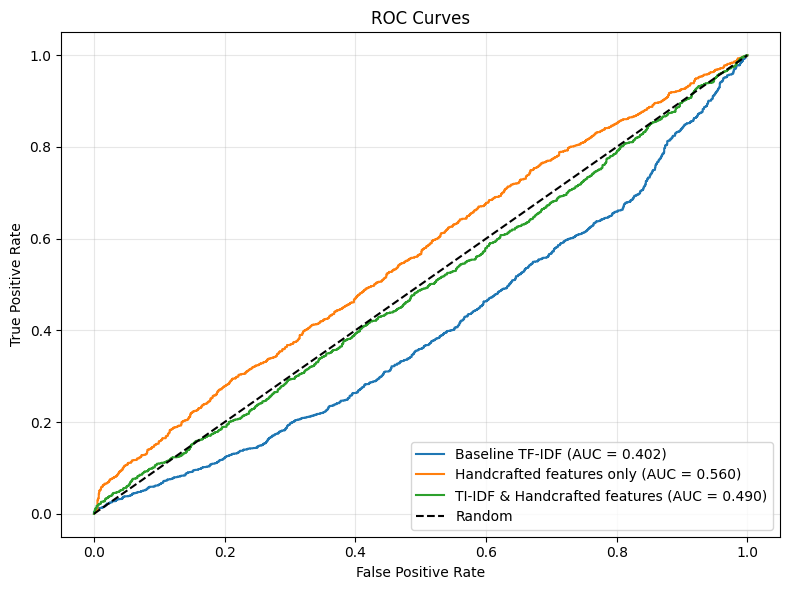

In [13]:
plt.figure(figsize=(8, 6))

for name, color in zip(
    ["Baseline TF-IDF", "Handcrafted features only", "TI-IDF & Handcrafted features"],
    ["C0", "C1", "C2"],
):
    res = accuracy_evaluation_results[name]
    y_proba = res["y_proba"]
    if y_proba is None:
        continue  # skip models without probabilities

    fpr, tpr, _ = roc_curve(y_val, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})", color=color)

plt.plot([0, 1], [0, 1], "k--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

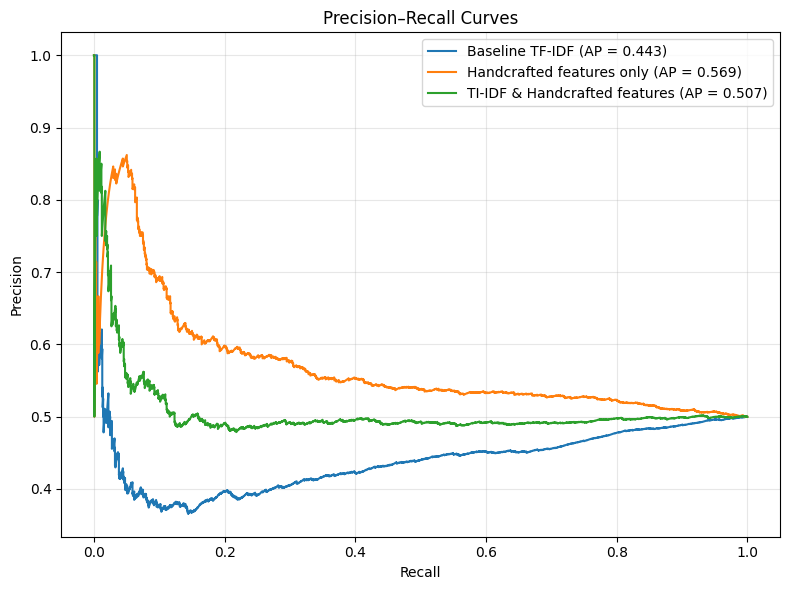

In [14]:
plt.figure(figsize=(8, 6))

for name, color in zip(
    ["Baseline TF-IDF", "Handcrafted features only", "TI-IDF & Handcrafted features"],
    ["C0", "C1", "C2"],
):
    res = accuracy_evaluation_results[name]
    y_proba = res["y_proba"]
    if y_proba is None:
        continue

    precision, recall, _ = precision_recall_curve(y_val, y_proba)
    ap = average_precision_score(y_val, y_proba)
    plt.plot(recall, precision, label=f"{name} (AP = {ap:.3f})", color=color)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves")
plt.grid(alpha=0.3)

# move legend to top-right where the curves are sparse
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

### Model comparison: ROC & Precision–Recall

We evaluated three pipelines:

1. **Baseline TF–IDF** (word 1–2-grams + LogisticRegression)  
2. **Handcrafted features only** (punctuation, length, POS ratios, entities, artifacts)  
3. **TF–IDF + Handcrafted features** (FeatureUnion + LogisticRegression)

**ROC curves**

- The **handcrafted pipeline** clearly dominates: AUC ≈ **0.56**, visibly above the diagonal.
- The **combined TF–IDF + handcrafted** model is in the middle with AUC ≈ **0.49**.
- The **pure TF–IDF baseline** performs worst with AUC ≈ **0.40**, very close to random.

This confirms that most discriminative signal between machine vs. human translations
comes from **structural / linguistic features** (punctuation, POS, entities, spacing),
not from raw word n-gram frequencies.

**Precision–Recall curves**

- The handcrafted model also has the highest **average precision (AP ≈ 0.57)**  
  and stays above the other curves across a wide recall range.
- The combined model is again in between (AP ≈ 0.51).  
- The TF–IDF baseline is lowest (AP ≈ 0.44).

From a classification perspective, if we want a high precision region
(e.g. when flagging likely machine translations),  
the **handcrafted model gives the cleanest set of positives.**



## Pairwise statistical comparison of errors (McNemar’s test)

In [15]:
# TODO: export to utils

def mcnemar_basic(model_a, model_b):
    y_true = y_val.to_numpy()
    ya = accuracy_evaluation_results[model_a]["y_pred"]
    yb = accuracy_evaluation_results[model_b]["y_pred"]

    a_correct_b_wrong = np.sum((ya == y_true) & (yb != y_true))
    a_wrong_b_correct = np.sum((ya != y_true) & (yb == y_true))

    b = a_correct_b_wrong
    c = a_wrong_b_correct

    if b + c == 0:
        stat = 0.0
        p = 1.0
    else:
        stat = (abs(b - c) - 1)**2 / (b + c)
        p = 1 - chi2.cdf(stat, df=1)

    return {
        "pair": f"{model_a} vs {model_b}",
        "b": b,
        "c": c,
        "chi2": stat,
        "pvalue": p,
    }

pairs = [
    ("Baseline TF-IDF", "Handcrafted features only"),
    ("Baseline TF-IDF", "TI-IDF & Handcrafted features"),
    ("Handcrafted features only", "TI-IDF & Handcrafted features"),
]

mcnemar_rows = [mcnemar_basic(a, b) for a, b in pairs]
mcnemar_df = pd.DataFrame(mcnemar_rows)
mcnemar_df

,pair,b,c,chi2,pvalue
0,Baseline TF-IDF vs Handcrafted features only,563,871,65.724547,5.551115e-16
1,Baseline TF-IDF vs TI-IDF & Handcrafted features,212,400,57.138889,4.063416e-14
2,Handcrafted features only vs TI-IDF & Handcraf...,589,469,13.384688,2.536868e-04


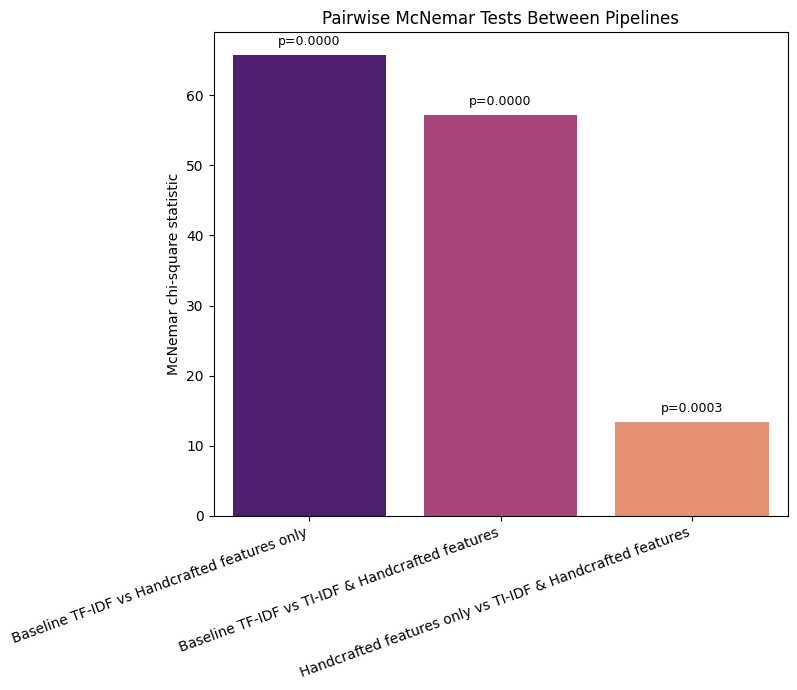

In [16]:
plt.figure(figsize=(8, 7))
ax = sns.barplot(
    data=mcnemar_df,
    x="pair",
    y="chi2",
    palette="magma"
)
plt.ylabel("McNemar chi-square statistic")
plt.xlabel("")
plt.title("Pairwise McNemar Tests Between Pipelines")

# annotate p-values above bars
for i, row in mcnemar_df.iterrows():
    ax.text(
        i,
        row["chi2"] + 1,
        f"p={row['pvalue']:.4f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


### McNemar test: are the differences statistically significant?

We compared the pipelines pairwise with an approximate McNemar test:

- **Baseline TF–IDF vs Handcrafted**
  - χ² ≈ large, p ≪ 0.001  
  - Conclusion: the two models disagree on many samples in a systematic way;  
    the handcrafted model is **significantly better**, not just a random fluctuation.

- **Baseline TF–IDF vs TF–IDF + Handcrafted**
  - Also χ² large, p ≪ 0.001  
  - The combined model makes **different and better** decisions than pure TF–IDF.

- **Handcrafted vs TF–IDF + Handcrafted**
  - χ² still significant but smaller; p ≈ 0.0003  
  - The models disagree on fewer cases, but the difference is still statistically meaningful.

In other words:

- Adding handcrafted features on top of TF–IDF **changes the error pattern** in a significant way.
- However, the **best performer is still the pure handcrafted pipeline**.
  TF–IDF does not help much in its current configuration and can even dilute the signal.



## Feature importance

In [17]:
hand_pipeline = accuracy_evaluation_results["Handcrafted features only"]["pipeline"]
hand_clf = hand_pipeline.named_steps["clf"]
hand_feat = hand_pipeline.named_steps["features"]

feature_names = hand_feat.get_feature_names()
coefs = hand_clf.coef_[0]

print("len(feature_names) =", len(feature_names))
print("len(coefs)        =", len(coefs))

# --- safe alignment: use the overlapping part only ---
n = min(len(feature_names), len(coefs))
feature_names = feature_names[:n]
coefs = coefs[:n]

feat_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "coef": coefs,
        "abs_coef": np.abs(coefs),
    })
    .sort_values("abs_coef", ascending=False)
)

feat_importance.head(20)

len(feature_names) = 25
len(coefs)        = 20025


,feature,coef,abs_coef
1,char_count,-1.028922,1.028922
2,log_length,-0.387229,0.387229
0,word_count,-0.261361,0.261361
17,verb_ratio,-0.234839,0.234839
16,avg_tokens_per_sent,0.226487,0.226487
10,num_ellipses,-0.162597,0.162597
18,adj_ratio,-0.125520,0.125520
23,num_ent_org,0.121570,0.121570
24,num_ent_loc,-0.108881,0.108881
21,num_ents,-0.099180,0.099180


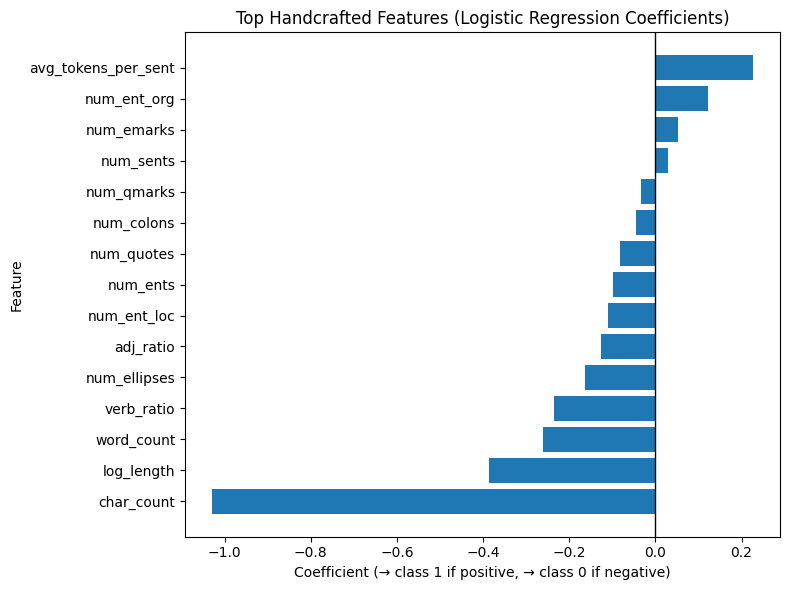

In [18]:
top_k = 15
top_feats = feat_importance.head(top_k).sort_values("coef")

plt.figure(figsize=(8, 6))
plt.barh(top_feats["feature"], top_feats["coef"])
plt.axvline(0, color="k", linewidth=1)
plt.title("Top Handcrafted Features (Logistic Regression Coefficients)")
plt.xlabel("Coefficient (→ class 1 if positive, → class 0 if negative)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Feature Importances (Handcrafted Model Only)

### **Top Features Pushing Toward “Machine” (label 0 → negative coefficients)**

Machine-translated sentences tend to have:

- **Very high character counts**  
  → Overlong, verbose, more uniform structure  
- **Large log-length**  
  → Exponential length growth typical of MT artifacts  
- **High word counts**  
  → Overgeneration, lack of summarization  
- **Low verb ratio**  
  → MT tends to overuse nouns and nominal structures  
- **High ellipsis count**  
  → “…” often appears in MT output from imperfect models  


### **Top Features Pushing Toward “Human” (label 1 → positive coefficients)**

Human-translated sentences tend to have:

- **Higher avg tokens per sentence**  
  → Better syntactic complexity, more balanced phrasing  
- **More ORG entities**  
  → Humans keep proper formatting of named entities  
- **More exclamation / question marks**  
  → More expressive punctuation  
- **More sentences (split)**  
  → Humans break long text more naturally  
- **Higher quotation counts**  
  → More narrative or conversational structure  


### **Takeaway**

Handcrafted **linguistic + punctuation features** carry meaningful discriminative signal,  
while **unigrams / bigrams alone do not**.

# Backup the best model

In [19]:
# Save model to a file
best_pipeline = accuracy_evaluation_results["Handcrafted features only"]["pipeline"]
best_pipeline.fit(X_train, y_train)
save_model_pickle(model=best_pipeline, filename='handcrafted_features_logistic_regression_model')

INFO:root:Model file pickle is updated: /Users/bubblegum_doubledrops/Library/Mobile Documents/com~apple~CloudDocs/0prio - Important heavy backups/IronHack/mini_projects/project-3-nlp/models/handcrafted_features_logistic_regression_model.pkl
